torch - deep learning library 
numpy - array operations    
cv2 - image processing
matplotlib - display images 
os - interact with files 
glob - finds files in the folders

saved trained ai model - fusion_model.pth
image will be resizes to 128x28 pixels 

the hardware configuration - checks whether cuda is available else just go with the cpu version 

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import glob

# --- CONFIGURATION ---
MODEL_PATH = "fusion_model.pth" 
IMG_SIZE = 256               

# --- HARDWARE SETUP: NATIVE CUDA ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Generator hardware: {DEVICE}")

🚀 Generator hardware: cuda


class FusionNet (nn.Model) - this is an ai architechure that creates CNN
there are three sections to these layers encoder , bottleneck layer , decoder

encoder - take images , extract images , shrink spacial size and increase depth , there will be six input channels 3 channels from image 1 and 3 channels from image 2 (R,G,B)

bottleneck layer - this is a deep thinking layer . it processes compressed information to figure out motion between frames 

decoder layer - this upscales the image. it takes compressed data back into reconstructed image .

final layer - the output is three channels (RGB image)

def foreward - this defies how a data showld flow through the network 
flow 
imput -> decoder -> bottleneck -> decoder -> output image   

In [ ]:
# --- 1. DEFINE THE MODEL ARCHITECTURE ---
class FusionNet(nn.Module):
    def __init__(self):
        super(FusionNet, self).__init__()
        self.enc1 = nn.Conv2d(6, 32, kernel_size=3, padding=1)
        self.enc2 = nn.Conv2d(32, 64, kernel_size=3, padding=1, stride=2) 
        self.enc3 = nn.Conv2d(64, 128, kernel_size=3, padding=1, stride=2)
        self.bottle = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.dec3 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)
        self.dec2 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        self.final = nn.Conv2d(32, 3, kernel_size=3, padding=1)
        
    def forward(self, x):
        e1 = F.relu(self.enc1(x))
        e2 = F.relu(self.enc2(e1))
        e3 = F.relu(self.enc3(e2))
        b = F.relu(self.bottle(e3))
        d3 = F.relu(self.dec3(b))
        d2 = F.relu(self.dec2(d3))
        return torch.sigmoid(self.final(d2))

model - FusionNet....... - this creates the neural netwrk 
then it loads the saved training weights . this means that ai remembers what it learned during the training 
model.eval() - sets the model to inference mode , not training mode 

In [ ]:
model = FusionNet().to(DEVICE)
if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval() 
    print("✅ AI Brain Loaded Successfully!")
else:
    print(f"❌ Error: {MODEL_PATH} not found. Train the model first.")

here you have the image warping function and generate intermediate frame function 
warping function 
    this part uses optical flow , ie how does the pixels move between each frames . then it moves the pixel accrgin to that motion it uses F.grid_sample()

In [ ]:
# --- 3. HELPER FUNCTIONS ---
def warp_tensor(img_tensor, flow_tensor):
    N, C, H, W = img_tensor.shape
    xx = torch.arange(0, W).view(1, -1).repeat(H, 1)
    yy = torch.arange(0, H).view(-1, 1).repeat(1, W)
    xx = xx.view(1, 1, H, W).repeat(N, 1, 1, 1)
    yy = yy.view(1, 1, H, W).repeat(N, 1, 1, 1)
    grid = torch.cat((xx, yy), 1).float()
    if img_tensor.device.type != 'cpu': 
        grid = grid.to(DEVICE)
    vgrid = grid + flow_tensor
    vgrid[:, 0, :, :] = 2.0 * vgrid[:, 0, :, :] / max(W - 1, 1) - 1.0
    vgrid[:, 1, :, :] = 2.0 * vgrid[:, 1, :, :] / max(H - 1, 1) - 1.0
    vgrid = vgrid.permute(0, 2, 3, 1)
    return F.grid_sample(img_tensor, vgrid, align_corners=True)

def generate_intermediate(frame1_path, frame2_path):
    print("   -> Reading images...")
    img1 = cv2.imread(frame1_path)
    img2 = cv2.imread(frame2_path)
    
    if img1 is None or img2 is None:
        print("   ❌ Error reading input images.")
        return None, None, None

    img1_s = cv2.resize(img1, (IMG_SIZE, IMG_SIZE))
    img2_s = cv2.resize(img2, (IMG_SIZE, IMG_SIZE))
    
    print("   -> Calculating Optical Flow...")
    prev_gray = cv2.cvtColor(img1_s, cv2.COLOR_BGR2GRAY)
    next_gray = cv2.cvtColor(img2_s, cv2.COLOR_BGR2GRAY)
    flow = cv2.calcOpticalFlowFarneback(prev_gray, next_gray, None, 0.5, 5, 25, 10, 5, 1.2, 0)
    
    t1 = torch.from_numpy(img1_s).permute(2, 0, 1).float().unsqueeze(0) / 255.0
    t2 = torch.from_numpy(img2_s).permute(2, 0, 1).float().unsqueeze(0) / 255.0
    t_flow = torch.from_numpy(flow).permute(2, 0, 1).float().unsqueeze(0)
    
    t1, t2, t_flow = t1.to(DEVICE), t2.to(DEVICE), t_flow.to(DEVICE)
    
    print("   -> Running CNN Fusion...")
    with torch.no_grad():
        warped_1 = warp_tensor(t1, t_flow * 0.5)
        warped_2 = warp_tensor(t2, t_flow * -0.5)
        cnn_input = torch.cat([warped_1, warped_2], dim=1)
        output = model(cnn_input)
        
    out_img = output.squeeze(0).permute(1, 2, 0).cpu().numpy()
    out_img = (out_img * 255).astype(np.uint8)
    
    return img1_s, out_img, img2_s

🚀 Generator hardware: cuda
✅ Advanced AI Brain Loaded Successfully!

--- Advanced Single Frame Interpolation Test ---


C:\Users\cempl\AppData\Local\Temp\ipykernel_26112\1923058370.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=D

⚠️ Automatically adding '.png' to the filename.

⏳ Generating single middle frame using Advanced U-Net...
✅ Success! Saved to: 'name.png'


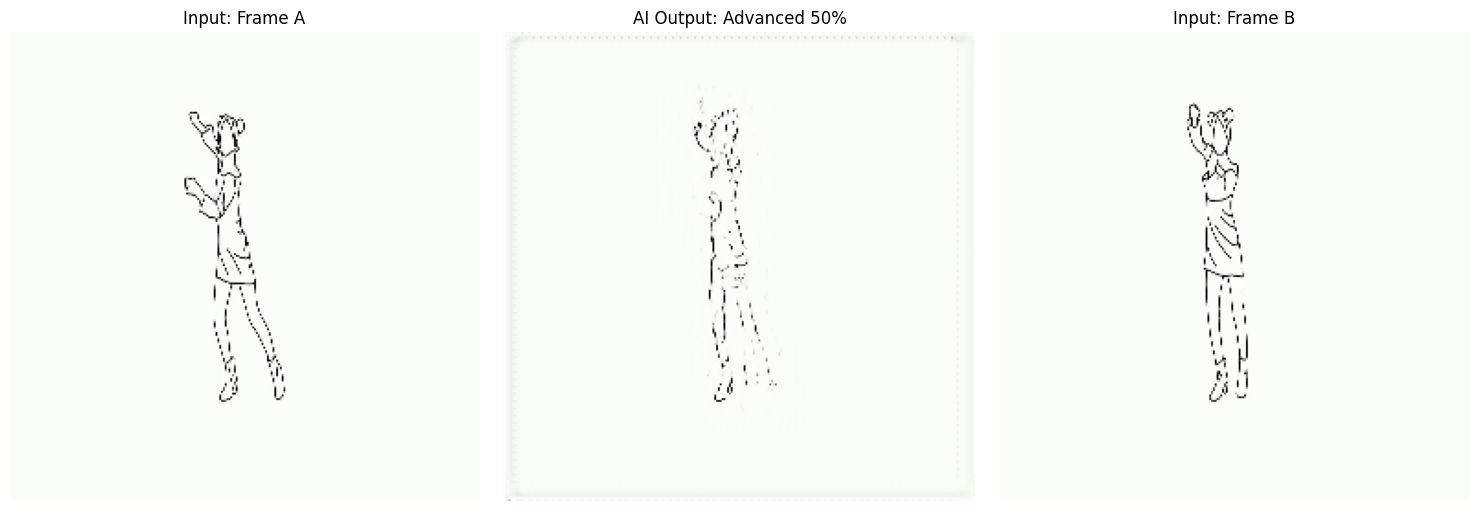

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

# --- CONFIGURATION ---
MODEL_PATH = "fusion_model.pth" 
IMG_SIZE = 256                  

# --- HARDWARE SETUP ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Generator hardware: {DEVICE}")

# --- 1. DEFINE THE ADVANCED MODEL ARCHITECTURE ---
# This MUST perfectly match the new Phase 5 skeleton
class AdvancedFusionNet(nn.Module):
    def __init__(self):
        super(AdvancedFusionNet, self).__init__()
        
        # Encoder
        self.enc1 = nn.Sequential(nn.Conv2d(6, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(inplace=True))
        self.enc2 = nn.Sequential(nn.Conv2d(32, 64, 3, 2, 1), nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.enc3 = nn.Sequential(nn.Conv2d(64, 128, 3, 2, 1), nn.BatchNorm2d(128), nn.ReLU(inplace=True))
        
        # Bottleneck
        self.bottle = nn.Sequential(nn.Conv2d(128, 128, 3, 1, 1), nn.BatchNorm2d(128), nn.ReLU(inplace=True))
        
        # Decoder + Skip Connections
        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)
        self.dec3 = nn.Sequential(nn.Conv2d(128, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        
        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        self.dec2 = nn.Sequential(nn.Conv2d(64, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(inplace=True))
        
        self.final = nn.Conv2d(32, 3, kernel_size=3, padding=1)
        
    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        
        b = self.bottle(e3)
        
        d3 = self.up3(b)
        d3 = torch.cat([d3, e2], dim=1) # <-- SKIP CONNECTION
        d3 = self.dec3(d3)
        
        d2 = self.up2(d3)
        d2 = torch.cat([d2, e1], dim=1) # <-- SKIP CONNECTION
        d2 = self.dec2(d2)
        
        return torch.sigmoid(self.final(d2))

# --- 2. LOAD THE TRAINED MODEL ---
model = AdvancedFusionNet().to(DEVICE)
if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    
    # CRITICAL FIX for Advanced Architecture: 
    # .eval() disables BatchNorm training updates to freeze the brain for inference
    model.eval() 
    print("✅ Advanced AI Brain Loaded Successfully!")
else:
    print(f"❌ Error: {MODEL_PATH} not found. Train the model first.")

# --- 3. UPGRADED WARPING LOGIC ---
def warp_tensor(img_tensor, flow_tensor):
    N, C, H, W = img_tensor.shape
    xx = torch.arange(0, W).view(1, -1).repeat(H, 1)
    yy = torch.arange(0, H).view(-1, 1).repeat(1, W)
    xx = xx.view(1, 1, H, W).repeat(N, 1, 1, 1)
    yy = yy.view(1, 1, H, W).repeat(N, 1, 1, 1)
    grid = torch.cat((xx, yy), 1).float()
    if img_tensor.device.type != 'cpu': 
        grid = grid.to(DEVICE)
    vgrid = grid + flow_tensor
    vgrid[:, 0, :, :] = 2.0 * vgrid[:, 0, :, :] / max(W - 1, 1) - 1.0
    vgrid[:, 1, :, :] = 2.0 * vgrid[:, 1, :, :] / max(H - 1, 1) - 1.0
    vgrid = vgrid.permute(0, 2, 3, 1)
    
    # Matching the Phase 5 border padding upgrade
    return F.grid_sample(img_tensor, vgrid, align_corners=True, padding_mode='border')

def generate_single_middle_frame(img1_s, img2_s):
    prev_gray = cv2.cvtColor(img1_s, cv2.COLOR_BGR2GRAY)
    next_gray = cv2.cvtColor(img2_s, cv2.COLOR_BGR2GRAY)
    
    flow = cv2.calcOpticalFlowFarneback(prev_gray, next_gray, None, 0.5, 5, 25, 10, 5, 1.2, 0)
    
    t1 = torch.from_numpy(img1_s).permute(2, 0, 1).float().unsqueeze(0) / 255.0
    t2 = torch.from_numpy(img2_s).permute(2, 0, 1).float().unsqueeze(0) / 255.0
    t_flow = torch.from_numpy(flow).permute(2, 0, 1).float().unsqueeze(0)
    
    t1, t2, t_flow = t1.to(DEVICE), t2.to(DEVICE), t_flow.to(DEVICE)
    
    with torch.no_grad():
        warped_1 = warp_tensor(t1, t_flow * 0.5)
        warped_2 = warp_tensor(t2, t_flow * -0.5)
        cnn_input = torch.cat([warped_1, warped_2], dim=1)
        output = model(cnn_input)
        
    out_img = output.squeeze(0).permute(1, 2, 0).cpu().numpy()
    out_img = (out_img * 255).astype(np.uint8)
    
    return out_img

# --- 4. INTERACTIVE SINGLE-FRAME EXECUTION ---
print("\n--- Advanced Single Frame Interpolation Test ---")

frame_A_path = input("Enter path to FIRST keyframe: ").strip()
frame_B_path = input("Enter path to SECOND keyframe: ").strip()
output_path = input("Enter the name to save (e.g., advanced_middle.png): ").strip()

# --- SAFETY CHECKS ---
if not output_path.lower().endswith(('.png', '.jpg', '.jpeg')):
    print("⚠️ Automatically adding '.png' to the filename.")
    output_path += '.png'

output_dir = os.path.dirname(output_path)
if output_dir != '' and not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)
# ---------------------

if os.path.exists(frame_A_path) and os.path.exists(frame_B_path):
    print(f"\n⏳ Generating single middle frame using Advanced U-Net...")
    
    imgA = cv2.resize(cv2.imread(frame_A_path), (IMG_SIZE, IMG_SIZE))
    imgB = cv2.resize(cv2.imread(frame_B_path), (IMG_SIZE, IMG_SIZE))
    
    middle_gen = generate_single_middle_frame(imgA, imgB)
    
    cv2.imwrite(output_path, middle_gen)
    print(f"✅ Success! Saved to: '{output_path}'")
    
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(cv2.cvtColor(imgA, cv2.COLOR_BGR2RGB))
    ax[0].set_title("Input: Frame A")
    ax[0].axis('off')
    
    ax[1].imshow(cv2.cvtColor(middle_gen, cv2.COLOR_BGR2RGB))
    ax[1].set_title("AI Output: Advanced 50%")
    ax[1].axis('off')
    
    ax[2].imshow(cv2.cvtColor(imgB, cv2.COLOR_BGR2RGB))
    ax[2].set_title("Input: Frame B")
    ax[2].axis('off')
    
    plt.tight_layout()
    plt.show()

else:
    print("\n❌ Error: Could not find one or both of your input files.")